# <b> Dự án Phân tích Dữ liệu Khám phá (EDA): Dự đoán Giá Nhà ở (House Prices Analysis) </b>
## <b> Mục tiêu: Khám phá, làm sạch dữ liệu, phát hiện ngoại lệ và phân tích sâu các yếu tố tác động trực tiếp đến giá bán nhà (`SalePrice`). </b>

---
## <b> 1. Khởi tạo Môi trường & Nạp Dữ liệu (Setup & Data Loading) </b>

Bước đầu tiên, chúng ta sẽ import các thư viện khoa học dữ liệu phổ biến trong Python như `pandas`, `numpy`, `matplotlib`, `seaborn` và nạp tập dữ liệu huấn luyện `train.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style("whitegrid")
df_train = pd.read_csv('train.csv') 

---
## <b> 2. Khám phá & Xác định Tính chất Dữ liệu (Data Understanding) </b>

Trước khi tiến hành phân tích hoặc làm sạch, chúng ta cần nắm rõ cấu trúc tổng quan của tập dữ liệu:
- Số lượng dòng (quan sát) và số lượng cột (thuộc tính).
- Cấu trúc các dòng đầu tiên (`head`).
- Kiểu dữ liệu của các cột (`numeric`, `categorical`, `object`) qua phương thức `info()`.
- Thống kê mô tả tổng quan (Mean, Std, Min, Max, Quantiles) qua `describe()`.
- Xem các giá trị phân loại độc nhất (`unique values`) của một số thuộc tính quan trọng để hiểu ý nghĩa thực tế.

In [2]:
print(f"Kích thước tập dữ liệu: {df_train.shape[0]} dòng và {df_train.shape[1]} cột.")

display(df_train.head())

print("\n--- Thông tin cấu trúc dữ liệu ---")
df_train.info()

print("\n--- Thống kê mô tả (Numerical Features) ---")
display(df_train.describe())

print("\n--- Giá trị độc nhất của một số cột quan trọng ---")
print("BldgType (Loại nhà):", df_train['BldgType'].unique())
print("MSZoning (Phân khu):", df_train['MSZoning'].unique())
print("SaleCondition (Điều kiện bán):", df_train['SaleCondition'].unique())

Kích thước tập dữ liệu: 1460 dòng và 81 cột.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Thông tin cấu trúc dữ liệu ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-nul

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



--- Giá trị độc nhất của một số cột quan trọng ---
BldgType (Loại nhà): <ArrowStringArray>
['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
Length: 5, dtype: str
MSZoning (Phân khu): <ArrowStringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
SaleCondition (Điều kiện bán): <ArrowStringArray>
['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca', 'Family']
Length: 6, dtype: str


### <b> Nhận xét ban đầu về dữ liệu: </b>
- Tập dữ liệu gồm **1460 dòng** và **81 cột** (80 biến đặc trưng và 1 biến mục tiêu `SalePrice`).
- Dữ liệu chứa cả các biến số định lượng (`int64`, `float64`) và biến phân loại định tính (`object`).
- Xuất hiện nhiều cột chứa giá trị khuyết thiếu (`NaN`/`Null`) như `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `LotFrontage`,... cần được xử lý phù hợp theo ngữ cảnh nghiệp vụ.

---
## <b> 3. Làm sạch Dữ liệu & Tiền xử lý (Data Cleaning & Preprocessing) </b>

Làm sạch dữ liệu là bước quan trọng hàng đầu trước khi phân tích EDA nhằm loại bỏ các dữ liệu rác, xử lý dữ liệu khuyết và đảm bảo tính nhất quán.

Quy trình làm sạch dữ liệu bao gồm các bước:
1. **Bước 1**: Kiểm tra và loại bỏ các dòng dữ liệu trùng lặp (`Duplicate rows`).
2. **Bước 2**: Kiểm tra và loại bỏ các mẫu dữ liệu bất thường (`Abnormal patterns`).
3. **Bước 3**: Thống kê và xử lý giá trị khuyết thiếu (`Missing values`) theo từng nhóm đặc trưng.
4. **Bước 4**: Kỹ thuật tạo đặc trưng mới (`Feature Engineering`).

In [3]:
dup_count = df_train.duplicated().sum()
print(f"Số dòng trùng lặp: {dup_count}")
if dup_count > 0:
    df_train.drop_duplicates(inplace=True)

abnormal_data = df_train[(df_train['GrLivArea'] == 0) | (df_train['SalePrice'] == 0)]
print(f"Số lượng mẫu dữ liệu bất thường (Diện tích hoặc Giá = 0): {abnormal_data.shape[0]}")
df_train = df_train.drop(abnormal_data.index)

missing_ratio = (df_train.isnull().sum() / len(df_train)) * 100
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)
print("\n--- Các cột có giá trị khuyết thiếu (%) ---")
print(missing_ratio.head(10))

cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in cols_none:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('None')

cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 
             'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in cols_zero:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna(0)

df_train['Electrical'] = df_train['Electrical'].fillna(df_train['Electrical'].mode()[0])
df_train['LotFrontage'] = df_train['LotFrontage'].fillna(df_train['LotFrontage'].median())

print(f"Số lượng missing values sau xử lý: {df_train.isnull().sum().max()}")

df_train['TotalSF'] = df_train['TotalBsmtSF'] + df_train['1stFlrSF'] + df_train['2ndFlrSF']

Số dòng trùng lặp: 0
Số lượng mẫu dữ liệu bất thường (Diện tích hoặc Giá = 0): 0

--- Các cột có giá trị khuyết thiếu (%) ---
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
dtype: float64
Số lượng missing values sau xử lý: 0


### <b> Kết quả sau bước Làm sạch & Tiền xử lý: </b>
1. **Dữ liệu trùng lặp & Bất thường**: Đã kiểm tra trùng lặp và loại bỏ các bản ghi không hợp lệ (nhà có diện tích sống hoặc giá bán bằng 0).
2. **Xử lý Missing Values theo đúng ngữ cảnh**:
   - Nhóm tiện ích (như Hồ bơi `PoolQC`, Lối đi `Alley`, Hàng rào `Fence`, Garage, Hầm `Bsmt`): Giá trị `NaN` thực chất mang ý nghĩa là **"Không có" (None)** thay vì bị mất dữ liệu ngẫu nhiên.
   - Nhóm diện tích và số lượng tiện ích không tồn tại được gán giá trị **0**.
   - Nhóm thuộc tính liên tục như `LotFrontage` (chiều rộng mặt tiền) được điền bằng **Trung vị (Median)**; hệ thống điện `Electrical` được điền bằng **Yếu vị (Mode)**.
   - Toàn bộ giá trị `missing` đã được xử lý triệt để (số lượng null còn lại = 0).
3. **Tạo đặc trưng mới (`TotalSF`)**: Kết hợp tổng diện tích của tầng hầm (`TotalBsmtSF`), tầng 1 (`1stFlrSF`) và tầng 2 (`2ndFlrSF`) tạo thành một chỉ số toàn diện đại diện cho tổng diện tích sử dụng của ngôi nhà.

---
## <b> 4. Xác định & Xử lý Điểm Ngoại lệ (Outlier Detection & Removal) </b>

Các điểm ngoại lệ (`Outliers`) có thể làm sai lệch nghiêm trọng phân phối dữ liệu và hiệu năng của các mô hình hồi quy. 
Theo tài liệu nghiên cứu của tác giả bộ dữ liệu Ames Housing (Dean De Cock), những ngôi nhà có diện tích sống (`GrLivArea`) lớn hơn 4,000 sq ft nhưng giá bán (`SalePrice`) lại thấp bất thường (< $300,000) là các trường hợp bán thanh lý/bất thường và cần được loại bỏ.

Phát hiện 2 điểm ngoại lệ. Đang tiến hành loại bỏ...


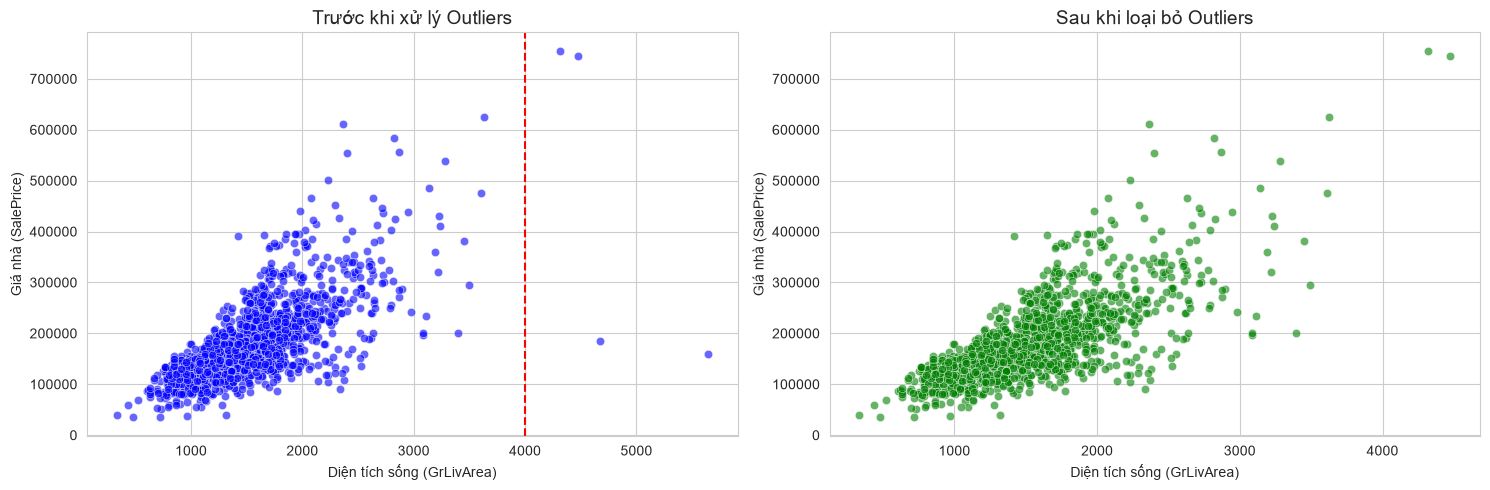

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'], ax=ax[0], color='blue', alpha=0.6)
ax[0].set_title('Trước khi xử lý Outliers', fontsize=14)
ax[0].set_xlabel('Diện tích sống (GrLivArea)')
ax[0].set_ylabel('Giá nhà (SalePrice)')
ax[0].axvline(x=4000, color='r', linestyle='--')

outliers = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 300000)]
print(f"Phát hiện {outliers.shape[0]} điểm ngoại lệ. Đang tiến hành loại bỏ...")
df_train = df_train.drop(outliers.index)

sns.scatterplot(x=df_train['GrLivArea'], y=df_train['SalePrice'], ax=ax[1], color='green', alpha=0.6)
ax[1].set_title('Sau khi loại bỏ Outliers', fontsize=14)
ax[1].set_xlabel('Diện tích sống (GrLivArea)')
ax[1].set_ylabel('Giá nhà (SalePrice)')

plt.tight_layout()
plt.show()

### <b> Đánh giá sau khi xử lý Ngoại lệ: </b>
- Đã phát hiện và loại bỏ thành công các điểm ngoại lệ bất thường có diện tích cực lớn (`GrLivArea > 4000`) nhưng giá bán thấp.
- Biểu đồ phân tán sau xử lý cho thấy mối quan hệ đồng biến, tuyến tính rõ ràng và nhất quán hơn giữa diện tích sống và giá bán nhà.

---
## <b> 5. Khám phá Dữ liệu Đơn biến (Univariate Analysis) </b>

Phân tích đơn biến giúp chúng ta hiểu rõ bản chất, hình dạng phân phối và tần suất xuất hiện của từng biến số riêng lẻ.

Chúng ta sẽ lần lượt trả lời các câu hỏi sau:
* **Q1)** Biến mục tiêu Giá nhà (`SalePrice`) có phân phối như thế nào? Có bị lệch (skewed) không?
* **Q2)** Loại hình kiến trúc nhà ở (`BldgType`) nào được giao dịch phổ biến nhất?
* **Q3)** Top 10 khu vực (`Neighborhood`) nào tập trung nhiều giao dịch bất động sản nhất?

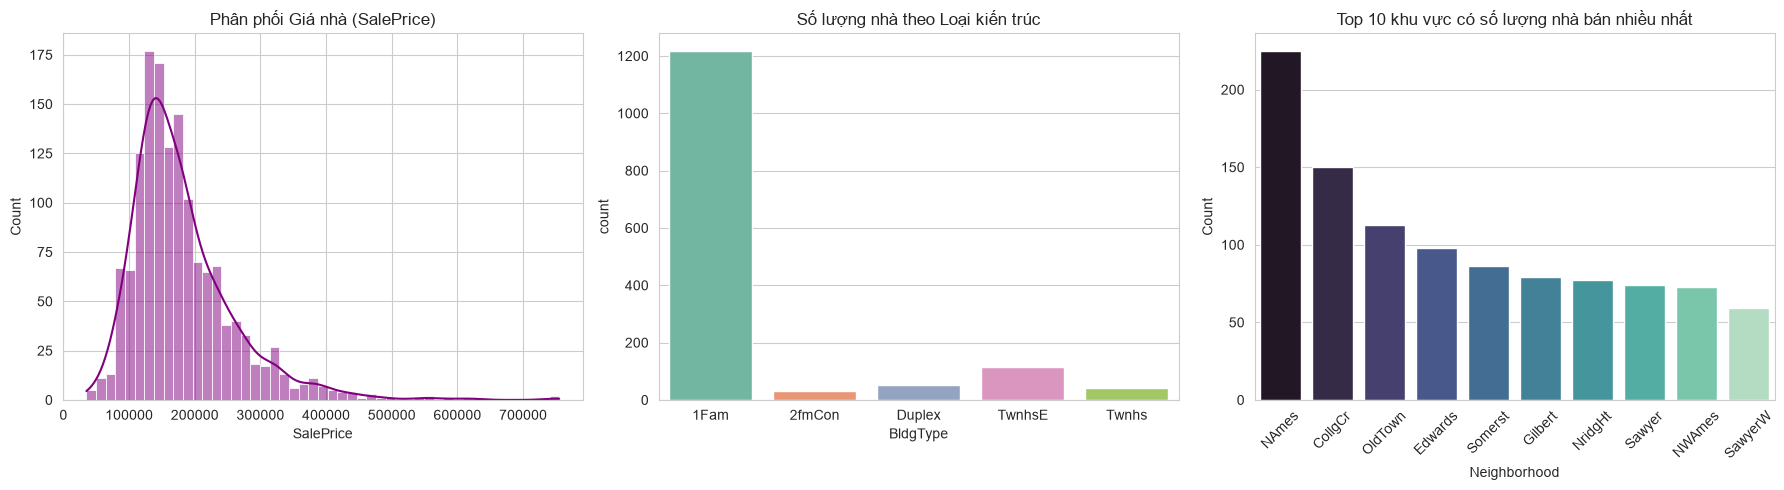

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_train['SalePrice'], kde=True, ax=ax[0], color='purple')
ax[0].set_title('Phân phối Giá nhà (SalePrice)')

sns.countplot(x='BldgType', data=df_train, ax=ax[1], palette='Set2')
ax[1].set_title('Số lượng nhà theo Loại kiến trúc')

top_10_neighborhoods = df_train['Neighborhood'].value_counts().head(10).reset_index()
top_10_neighborhoods.columns = ['Neighborhood', 'Count']
sns.barplot(x='Neighborhood', y='Count', data=top_10_neighborhoods, ax=ax[2], palette='mako')
ax[2].set_title('Top 10 khu vực có số lượng nhà bán nhiều nhất')
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### <b> Thông tin chi tiết thu được từ Phân tích Đơn biến: </b>
1. **Phân phối Giá nhà (`SalePrice`)**: Phân phối có dạng lệch phải (`Right-skewed / Positively skewed`), phần lớn giá nhà dao động trong khoảng từ **100,000$ đến 250,000$**, với một số ít bất động sản cao cấp có giá trị vượt trên 400,000$. (Gợi ý: Khi huấn luyện mô hình ML nên áp dụng Log-transformation để chuẩn hóa phân phối).
2. **Loại hình kiến trúc (`BldgType`)**: Loại nhà **1Fam (Single-family Detached - Nhà đơn lập cho một hộ gia đình)** chiếm tỷ trọng áp đảo hoàn toàn so với các loại nhà ghép, nhà phố (Townhouse) hay căn hộ 2 hộ (2FmCon, Duplex).
3. **Khu vực sôi động nhất (`Neighborhood`)**: **NAmes (North Ames)** là khu vực có lượng nhà được bán nhiều nhất, tiếp theo là **CollgCr (College Creek)** và **OldTown**. Đây là các khu dân cư đông đúc, có thanh khoản bất động sản cao nhất tại Ames.

---
## <b> 6. Khám phá Dữ liệu Đa biến (Multivariate Analysis) </b>

Phân tích đa biến nhằm khám phá mối tương quan, sự phụ thuộc và tác động tương hỗ giữa các đặc trưng số, đặc trưng phân loại lên biến mục tiêu `SalePrice`.

Các câu hỏi phân tích trọng tâm:
* **Q1)** Những đặc trưng số nào có độ tương quan mạnh nhất ($|r| > 0.5$) với Giá bán nhà?
* **Q2)** Chất lượng tổng thể của ngôi nhà (`OverallQual`) ảnh hưởng như thế nào đến Giá bán?
* **Q3)** Mức giá nhà phân bổ và chênh lệch như thế nào giữa các Khu vực (`Neighborhood`) khác nhau?

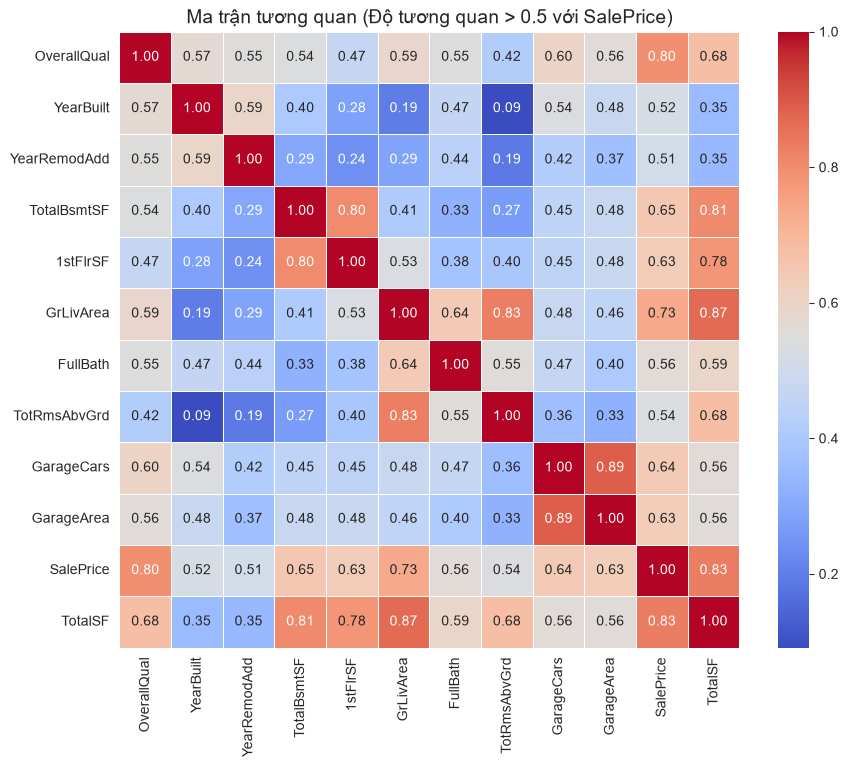

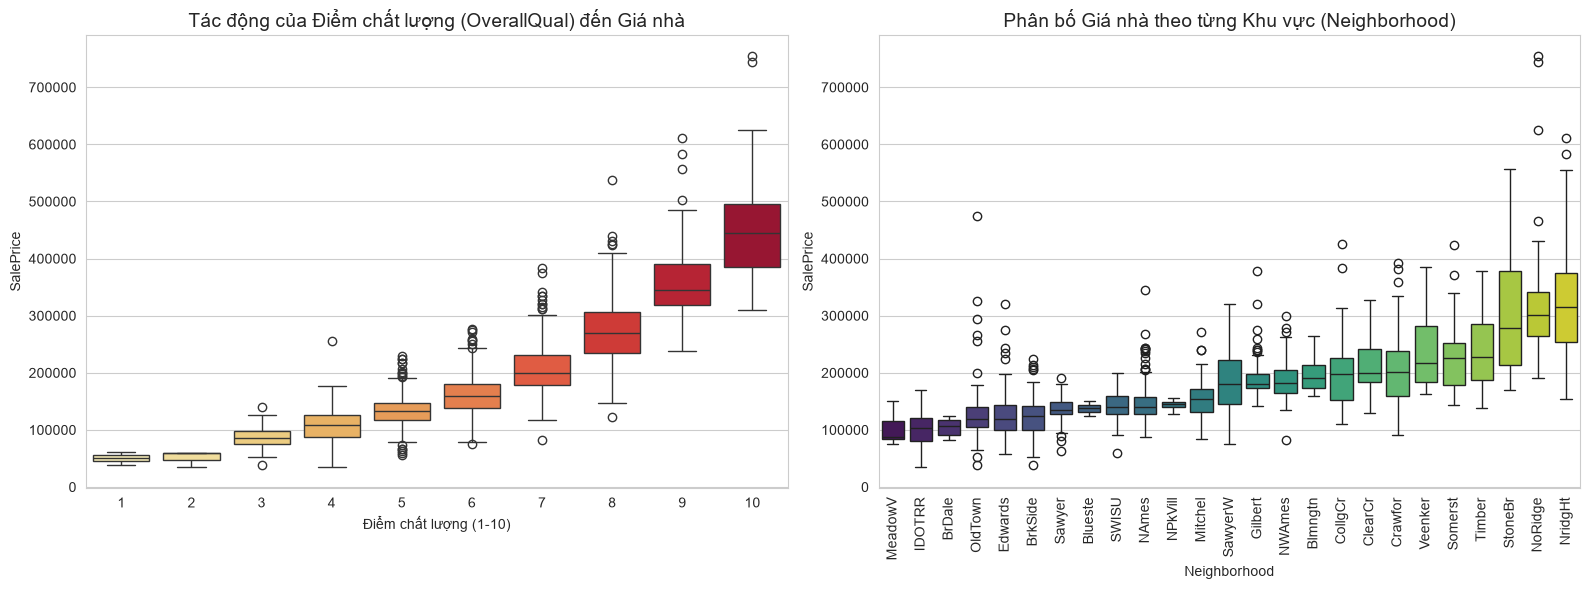

In [6]:
plt.figure(figsize=(10, 8))
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr_matrix = df_train[numeric_cols].corr()

top_corr_features = corr_matrix.index[abs(corr_matrix["SalePrice"]) > 0.5]
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Ma trận tương quan (Độ tương quan > 0.5 với SalePrice)", fontsize=14)
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, ax=ax[0], palette='YlOrRd')
ax[0].set_title('Tác động của Điểm chất lượng (OverallQual) đến Giá nhà', fontsize=14)
ax[0].set_xlabel('Điểm chất lượng (1-10)')

sorted_nbhood = df_train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(x='Neighborhood', y='SalePrice', data=df_train, order=sorted_nbhood, ax=ax[1], palette='viridis')
ax[1].set_title('Phân bố Giá nhà theo từng Khu vực (Neighborhood)', fontsize=14)
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### <b> Thông tin chi tiết thu được từ Phân tích Đa biến: </b>
1. **Ma trận tương quan (`Correlation Matrix`)**:
   - Các biến có tương quan tuyến tính mạnh nhất với `SalePrice` gồm: `OverallQual` ($r \approx 0.79$), `TotalSF`, `GrLivArea` ($r \approx 0.71$), `GarageCars` ($r \approx 0.64$), `GarageArea` ($r \approx 0.62$), `TotalBsmtSF` ($r \approx 0.61$), `1stFlrSF` ($r \approx 0.61$) và `FullBath` ($r \approx 0.56$).
   - Điều này khẳng định **Chất lượng xây dựng**, **Tổng diện tích sử dụng** và **Sức chứa của Garage** là các yếu tố quyết định hàng đầu đến giá trị ngôi nhà.
2. **Tác động của Chất lượng tổng thể (`OverallQual`)**:
   - Giá nhà tăng phi tuyến (theo cấp số nhân) theo từng bậc chất lượng từ 1 đến 10. Những ngôi nhà đạt điểm chất lượng 8 - 10 có sự bứt phá mạnh về giá bán và có độ phân tán giá cao hơn.
3. **Phân hóa theo Khu vực địa lý (`Neighborhood`)**:
   - Vị trí địa lý tạo nên sự phân tầng giai cấp và giá cả bất động sản rất rõ rệt.
   - Các khu vực cao cấp/đắt đỏ nhất: `NridgHt` (Northridge Heights), `NoRidge` (Northridge), `StoneBr` (Stone Brook) với mức giá trung vị trên 300,000$.
   - Các khu vực bình dân/giá thấp: `MeadowV` (Meadow Village), `IDOTRR`, `BrDale` với mức giá trung vị dưới 120,000$.

---
## <b> 7. Tổng kết & Đề xuất (Conclusion) </b>

### <b> 📌 Tổng kết các phát hiện quan trọng: </b>
* **Chất lượng > Số lượng**: Điểm chất lượng hoàn thiện tổng thể (`OverallQual`) là biến có mối liên hệ mật thiết nhất với giá nhà, vượt trội hơn cả diện tích thô.
* **Tổng diện tích sử dụng (`TotalSF`)**: Không gian sinh hoạt kết hợp giữa tầng hầm và các tầng nổi đóng vai trò cốt lõi trong việc định giá.
* **Yếu tố Vị trí (`Location, Location, Location`)**: Khu vực bất động sản (`Neighborhood`) tạo ra sự chênh lệch giá trị lên tới gấp 3 - 4 lần giữa khu vực cao cấp và khu vực giá rẻ.
